# Module 2 — Chemical Kinetics in the Atmosphere
### B4 Chemistry in the Atmosphere · companion notebook

Covers: first-order decay (Fig 2.1), the A→B→C chain reaction and steady-state approximation,
Exercise 3 (exact vs. steady-state solution for A⇌B), Arrhenius kinetics (Fig 2.3), and the
low-/high-pressure limits of a ter-molecular reaction (Exercise 4).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## Figure 2.1 — first-order decay for different k

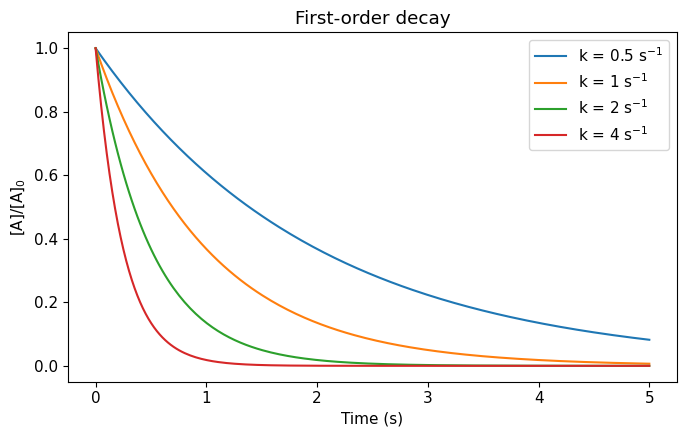

In [2]:
t = np.linspace(0, 5, 200)
A0 = 1.0

plt.figure()
for k in [0.5, 1, 2, 4]:
    plt.plot(t, A0*np.exp(-k*t), label=f'k = {k} s$^{{-1}}$')
plt.xlabel('Time (s)')
plt.ylabel('[A]/[A]$_0$')
plt.title('First-order decay')
plt.legend()
plt.tight_layout()
plt.show()

## The A → B → C chain reaction

$$\frac{d[A]}{dt}=-k_1[A],\qquad \frac{d[B]}{dt}=k_1[A]-k_2[B],\qquad \frac{d[C]}{dt}=k_2[B]$$

We solve this numerically for two cases from the notes: $(k_1,k_2)=(1,2)$ s⁻¹ and $(1,10)$ s⁻¹,
and compare $[B]$ against the steady-state approximation $[B]_{ss}=k_1[A]/k_2$.

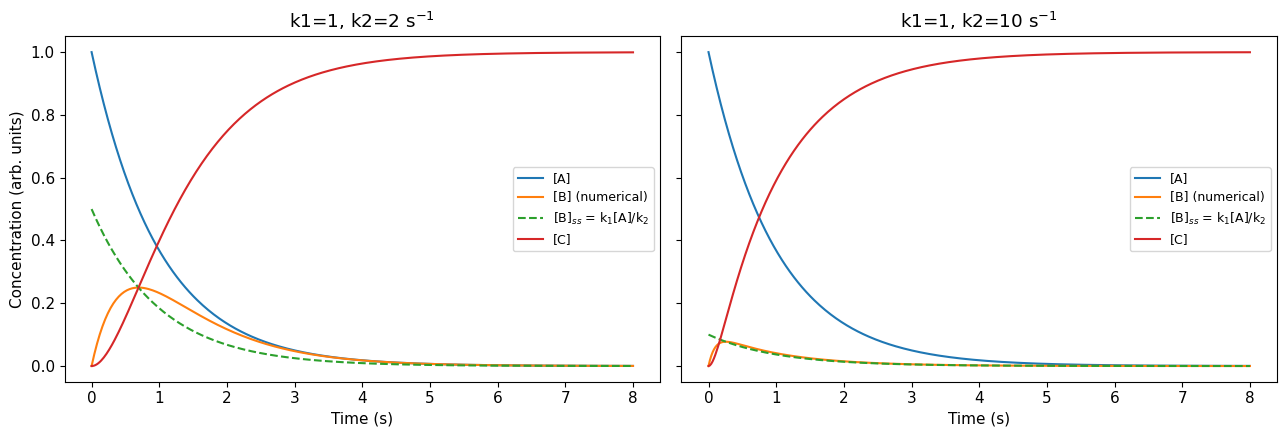

Notice: the larger k2 is relative to k1, the faster [B] settles onto the
steady-state curve, and the smaller its peak concentration becomes.


In [3]:
def abc_system(y, t, k1, k2):
    A, B, C = y
    dA = -k1*A
    dB = k1*A - k2*B
    dC = k2*B
    return [dA, dB, dC]

t = np.linspace(0, 8, 400)
y0 = [1.0, 0.0, 0.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (k1, k2) in zip(axes, [(1, 2), (1, 10)]):
    sol = odeint(abc_system, y0, t, args=(k1, k2))
    A, B, C = sol.T
    B_ss = k1 * A / k2   # steady-state approximation

    ax.plot(t, A, label='[A]')
    ax.plot(t, B, label='[B] (numerical)')
    ax.plot(t, B_ss, '--', label='[B]$_{ss}$ = k$_1$[A]/k$_2$')
    ax.plot(t, C, label='[C]')
    ax.set_xlabel('Time (s)')
    ax.set_title(f'k1={k1}, k2={k2} s$^{{-1}}$')
    ax.legend(fontsize=9)
axes[0].set_ylabel('Concentration (arb. units)')
plt.tight_layout()
plt.show()

print("Notice: the larger k2 is relative to k1, the faster [B] settles onto the")
print("steady-state curve, and the smaller its peak concentration becomes.")

## Exercise 3 — steady-state error for $A \rightleftharpoons B$

Exact solution (Eq 9 in the notes):

$$x(t) = \frac{k_f a}{k_f+k_b}\Big[1-\exp\big(-(k_f+k_b)t\big)\Big]$$

We compare this exact solution to the naive steady-state approximation
$x_{ss} = k_f a / (k_f+k_b)$ (i.e. the long-time limit applied at all t), for a few ratios of
$k_f/k_b$.

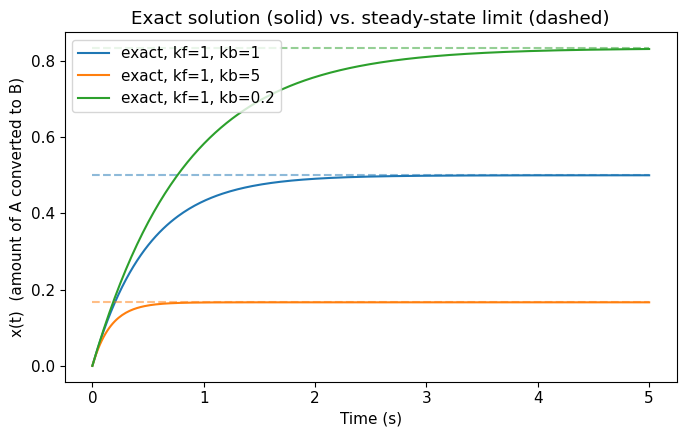

The steady-state approximation is only valid once t >> 1/(kf+kb).
For small t it substantially overestimates x -- there hasn't been time to equilibrate.


In [4]:
def x_exact(t, kf, kb, a=1.0):
    return (kf*a/(kf+kb)) * (1 - np.exp(-(kf+kb)*t))

t = np.linspace(0, 5, 300)
a = 1.0

plt.figure()
for kf, kb in [(1, 1), (1, 5), (1, 0.2)]:
    x = x_exact(t, kf, kb, a)
    x_ss = (kf*a/(kf+kb)) * np.ones_like(t)
    plt.plot(t, x, label=f'exact, kf={kf}, kb={kb}')
    plt.plot(t, x_ss, '--', color=plt.gca().lines[-1].get_color(), alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('x(t)  (amount of A converted to B)')
plt.title('Exact solution (solid) vs. steady-state limit (dashed)')
plt.legend()
plt.tight_layout()
plt.show()

print("The steady-state approximation is only valid once t >> 1/(kf+kb).")
print("For small t it substantially overestimates x -- there hasn't been time to equilibrate.")

## Arrhenius kinetics (Fig 2.3 style)

$$k(T) = A \exp(-E_a/RT)$$

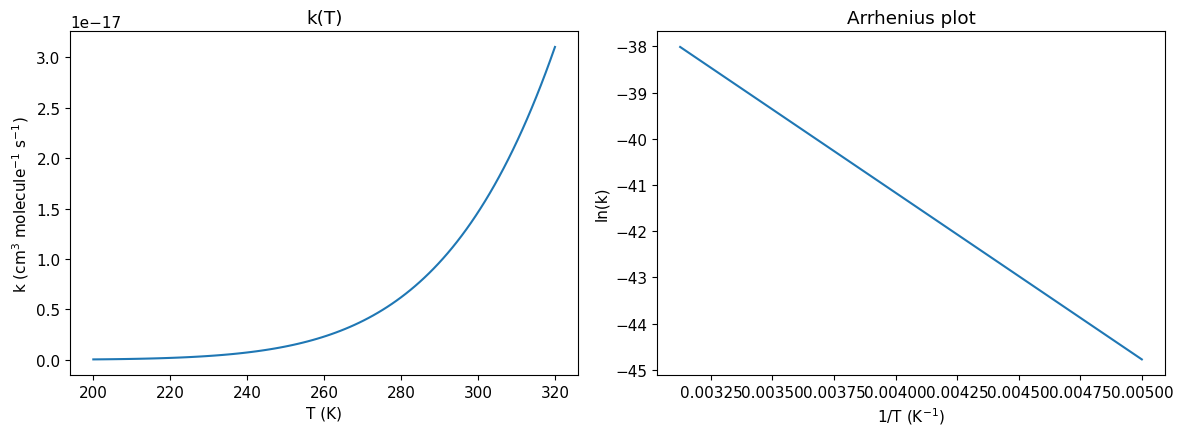

Fitted Ea = 30000.0 J/mol (input: 30000.0)
Fitted A  = 2.450e-12 (input: 2.450e-12)


In [5]:
R = 8.314   # J/mol/K

def arrhenius(T, A_pref, Ea):
    return A_pref * np.exp(-Ea / (R * T))

# Representative values in the ballpark of OH + CH4 (illustrative, not the exact IUPAC value)
A_pref = 2.45e-12   # cm^3 molecule^-1 s^-1
Ea = 30.0e3          # J/mol

T = np.linspace(200, 320, 100)
k = arrhenius(T, A_pref, Ea)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(T, k)
axes[0].set_xlabel('T (K)')
axes[0].set_ylabel('k (cm$^3$ molecule$^{-1}$ s$^{-1}$)')
axes[0].set_title('k(T)')

axes[1].plot(1/T, np.log(k))
axes[1].set_xlabel('1/T (K$^{-1}$)')
axes[1].set_ylabel('ln(k)')
axes[1].set_title('Arrhenius plot')
plt.tight_layout()
plt.show()

# Recover A and Ea by linear regression on the Arrhenius plot, as you would with real data
slope, intercept = np.polyfit(1/T, np.log(k), 1)
Ea_fit = -slope * R
A_fit = np.exp(intercept)
print(f"Fitted Ea = {Ea_fit:.1f} J/mol (input: {Ea:.1f})")
print(f"Fitted A  = {A_fit:.3e} (input: {A_pref:.3e})")

## Exercise 4 — low-/high-pressure limits of a ter-molecular reaction

$$[I_{2}^{\ast}] = \frac{k_1[I]^2}{k_{col}[M]+k_d}, \qquad \frac{d[I_2]}{dt}=k_{col}[M][I_{2}^{\ast}]$$

We plot the *exact* rate (Eq 6) against the low-pressure (Eq 7, $\propto [M]$) and high-pressure
(Eq 8, independent of $[M]$) limiting forms, as a function of $[M]$.

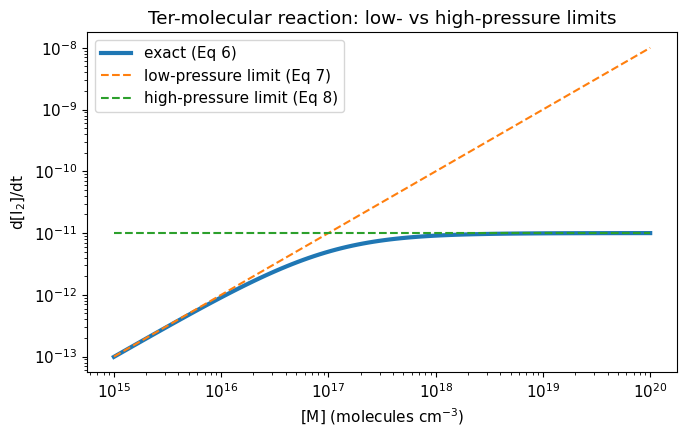

In [6]:
k1, kd, kcol = 1e-31, 1e7, 1e-10   # illustrative values (not literature-accurate)
I_conc = 1e10                       # molecules/cm^3, held fixed

M_range = np.logspace(15, 20, 100)  # molecules/cm^3

rate_exact = kcol * M_range * (k1 * I_conc**2) / (kcol * M_range + kd)
rate_low   = M_range * I_conc**2 * (k1 * kcol / kd)      # Eq 7
rate_high  = k1 * I_conc**2 * np.ones_like(M_range)       # Eq 8

plt.figure()
plt.loglog(M_range, rate_exact, label='exact (Eq 6)', lw=3)
plt.loglog(M_range, rate_low, '--', label='low-pressure limit (Eq 7)')
plt.loglog(M_range, rate_high, '--', label='high-pressure limit (Eq 8)')
plt.xlabel('[M] (molecules cm$^{-3}$)')
plt.ylabel('d[I$_2$]/dt')
plt.title('Ter-molecular reaction: low- vs high-pressure limits')
plt.legend()
plt.tight_layout()
plt.show()

## Exercises

1. **A→B→C in the opposite limit.** Re-run the chain-reaction solver with $k_2 < k_1$ (e.g.
   $k_1=10$, $k_2=1$). Does the steady-state approximation for [B] still work? Why/why not —
   connect your answer to the "Common question" box in the notes.

2. **Steady-state error, quantified.** For Exercise 3, compute $|x(t) - x_{ss}|/x_{ss}$ at
   $t = 1/(k_f+k_b)$ and at $t = 5/(k_f+k_b)$, for several $k_f/k_b$ ratios. At what multiple of
   the equilibration timescale is the steady-state approximation good to better than 5%?

3. **Real kinetics data.** Look up the IUPAC or JPL recommended Arrhenius parameters for OH + CH₄
   (or another reaction of your choice) and redo the Arrhenius fit above with the literature $A$
   and $E_a$. Over what temperature range does the simple two-parameter Arrhenius form fit well?

4. **Falloff curve.** The Troe expression smoothly connects the low- and high-pressure limits
   rather than switching abruptly. Look up the Troe form (or the simpler Lindemann–Hinshelwood
   expression $k = \dfrac{k_0[M]k_\infty}{k_0[M]+k_\infty}$) and overlay it on the plot above —
   how much does it differ from the "exact" curve already plotted (which *is* essentially the
   Lindemann form for this toy reaction)?